# 🌱 Relatório Estatístico — Registro Nacional de Cultivares (RNC)

> **Fonte de dados:** SNPC/MAPA — baixado automaticamente se ausente localmente.  
> **Filtro Aplicado:** Excluindo registros de 2026 (ano incompleto)

---

## Seções

### 🔧 Dados
0. [Pipeline de Dados — Download e Limpeza](#0-pipeline)
1. [Carregamento e Pré-processamento](#1-carregamento)
2. [Análise de Valores Nulos](#2-nulos)
3. [Visão Geral das Colunas](#3-visao-geral)

### 📦 O que é registrado
4. [Cultivares Mais Comuns](#4-cultivares)
5. [Distribuição por Grupo de Espécie](#5-grupos)

### 📈 Tendências Temporais
6. [Crescimento Anual de Registros](#6-crescimento-anual)
7. [Evolução Anual por Grupo de Espécie](#7-evolucao-grupos)
8. [Adoção do Nº de Formulário ao Longo do Tempo](#8-formulario-ano)

### 🏭 Quem registra
9. [Classificação de Mantenedores por Setor](#9-setores)
10. [Setor Público — Detalhamento](#10-publico)
11. [Setor Misto — Detalhamento](#11-misto)
12. [Mantenedores Estrangeiros vs. Nacionais](#12-estrangeiros)

### 🔬 Estrutura do Registro
13. [Composição dos Grupos por Setor](#13-grupos-setor)
14. [Registros sem Cultivar Nomeada](#14-sem-cultivar)
15. [Diversidade de Espécies por Mantenedor](#15-diversidade)

### 💰 Concentração de Mercado
16. [Líderes: Soja e Milho](#16-soja-milho)
17. [Mantenedores nas Cultivares Mais Comuns](#17-lideres)
18. [Concentração de Mercado por Espécie](#18-concentracao)

### ⏳ Ciclo de Vida do Registro
19. [Nulos por Ano — Mantenedor](#19-nulos-ano)
20. [Tempo entre Formulário e Registro](#20-tempo-registro)
21. [Registros Expirados](#21-expirados)

---
## 0. Pipeline de Dados — Download e Limpeza <a id='0-pipeline'></a>

O módulo `data_pipeline.py` centraliza dois processos:

| Etapa | Descrição |
|---|---|
| **Download automático** | Faz POST no site do SNPC/MAPA e salva `relatorio_cultivares.csv`. Só executa se o arquivo não existir localmente. |
| **Limpeza de dados** | Corrige aspas redundantes, remove tags HTML residuais, normaliza barras invertidas escapadas (`\\'` → `'`), converte tipos, preenche vazios com `NaN` real e adiciona a coluna `ANO`. |

### Problemas encontrados no CSV bruto

| Problema | Colunas Afetadas | Tratamento |
|---|---|---|
| Aspas simples `'` circundando valor | `CULTIVAR` | Removidas via regex |
| Aspas duplas `"` circundando valor | `CULTIVAR` | Removidas via regex |
| Tags HTML residuais (`</I>`, `<i/>`) | `NOME CIENTÍFICO` | Removidas via regex |
| Barras invertidas escapadas (`\\'`) | `NOME COMUM`, `NOME CIENTÍFICO` | Normalizadas para `'` |
| Células vazias / só espaços | Todas | Convertidas para `NaN` genuíno |
| `Nº FORMULÁRIO` como float com NaN | `Nº FORMULÁRIO` | Convertido para `Int64` nullable |
| Datas como string `dd/mm/yyyy` | `DATA DO REGISTRO`, `DATA DE VALIDADE` | Convertidas para `datetime64` |

---
## 1. Carregamento e Pré-processamento <a id='1-carregamento'></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_pipeline import (
    carregar_dados,
    COL_DATA_REG   as COL_DATA,
    COL_MANTENEDOR,
    COL_CULTIVAR,
    COL_FORMULARIO,
    COL_NOME_COM,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

df_raw = carregar_dados(imprimir_qualidade=True)
df = df_raw[df_raw['ANO'] != 2026].copy()
print(f'\n📅 Após filtro de 2026: {len(df):,} registros')

PUB_KW   = ['universidade', 'empresa brasileira', 'instituto',
             'empresa de pesquisa agropecuária', 'departamento de sementes',
             'secretaria da agricultura', 'agência goiana']
MISTO_KW = ['fundação', 'cooperativa']

def classify_setor(nome):
    if pd.isna(nome): return 'Nulo'
    n = nome.lower()
    for kw in PUB_KW:
        if kw in n: return 'Público'
    for kw in MISTO_KW:
        if kw in n: return 'Misto'
    return 'Privado'

df['SETOR'] = df[COL_MANTENEDOR].apply(classify_setor)

13:21:35 [INFO] 📂 Arquivo local encontrado: 'relatorio_cultivares.csv' — pulando download.
13:21:35 [INFO] 📥 Leitura bruta: 37733 registros | 10 colunas
13:21:35 [INFO] 🧹 Iniciando limpeza dos dados…
13:21:35 [INFO] ✅ Limpeza concluída — 37733 registros | 11 colunas



QUALIDADE DOS DADOS PÓS-LIMPEZA
📦 Registros : 37,733
📋 Colunas   : 11

Colunas com valores ausentes:
                                Total Nulos  % Nulos
Nº FORMULÁRIO                         23639    62.65
MANTENEDOR (REQUERENTE) (NOME)         3940    10.44
CULTIVAR                               3841    10.18


📅 Após filtro de 2026: 37,101 registros


---
## 2. Análise de Valores Nulos <a id='2-nulos'></a>

In [2]:
def analise_nulos(df):
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False).to_frame(name='Total Nulos')
    nulos['% Nulos'] = (nulos['Total Nulos'] / len(df) * 100).round(2)

    print(f'📊 Total de registros no dataset: {len(df):,}')
    print(f'❌ Nulos em Nº FORMULÁRIO: {df[COL_FORMULARIO].isnull().sum():,}')
    print(f'❌ Nulos em MANTENEDOR:    {df[COL_MANTENEDOR].isnull().sum():,}')

    return nulos.style.background_gradient(cmap='Reds')

analise_nulos(df)

📊 Total de registros no dataset: 37,101
❌ Nulos em Nº FORMULÁRIO: 23,639
❌ Nulos em MANTENEDOR:    3,669


,Total Nulos,% Nulos
Nº FORMULÁRIO,23639,63.720000
MANTENEDOR (REQUERENTE) (NOME),3669,9.890000
CULTIVAR,3570,9.620000


---
## 3. Visão Geral das Colunas <a id='3-visao-geral'></a>

In [3]:
res_col = pd.DataFrame({
    'Tipo'    : df.drop(columns='SETOR').dtypes.astype(str),
    'Nulos'   : df.drop(columns='SETOR').isnull().sum(),
    '% Nulos' : (df.drop(columns='SETOR').isnull().sum() / len(df) * 100).round(2),
})
res_col.style.background_gradient(subset=['% Nulos'], cmap='Reds')

,Tipo,Nulos,% Nulos
CULTIVAR,str,3570,9.620000
NOME COMUM,str,0,0.000000
NOME CIENTÍFICO,str,0,0.000000
GRUPO DA ESPÉCIE,str,0,0.000000
SITUAÇÃO,str,0,0.000000
Nº FORMULÁRIO,Int64,23639,63.720000
Nº REGISTRO,Int64,0,0.000000
DATA DO REGISTRO,datetime64[us],0,0.000000
DATA DE VALIDADE DO REGISTRO,datetime64[us],0,0.000000
MANTENEDOR (REQUERENTE) (NOME),str,3669,9.890000


---
## 4. Cultivares Mais Comuns <a id='4-cultivares'></a>

In [4]:
top_cultivares = (
    df.groupby(COL_NOME_COM)
    .agg(Registros=(COL_NOME_COM, 'count'))
    .reset_index()
    .sort_values('Registros', ascending=False)
    .head(30)
)
top_cultivares.index = range(1, 31)
display(top_cultivares.style.background_gradient(subset=['Registros'], cmap='YlGn'))

,NOME COMUM,Registros
1,Milho,6179
2,Soja,2728
3,Orquídea,1613
4,Tomate/Tomate-rasteiro,1396
5,Sorgo,1228
6,Crisântemo/Crisântemo-da-China,869
7,Alface,673
8,"Pimentão, Pimenta",654
9,Eucalipto,613
10,Fumo/Tabaco,524


---
## 5. Distribuição por Grupo de Espécie <a id='5-grupos'></a>

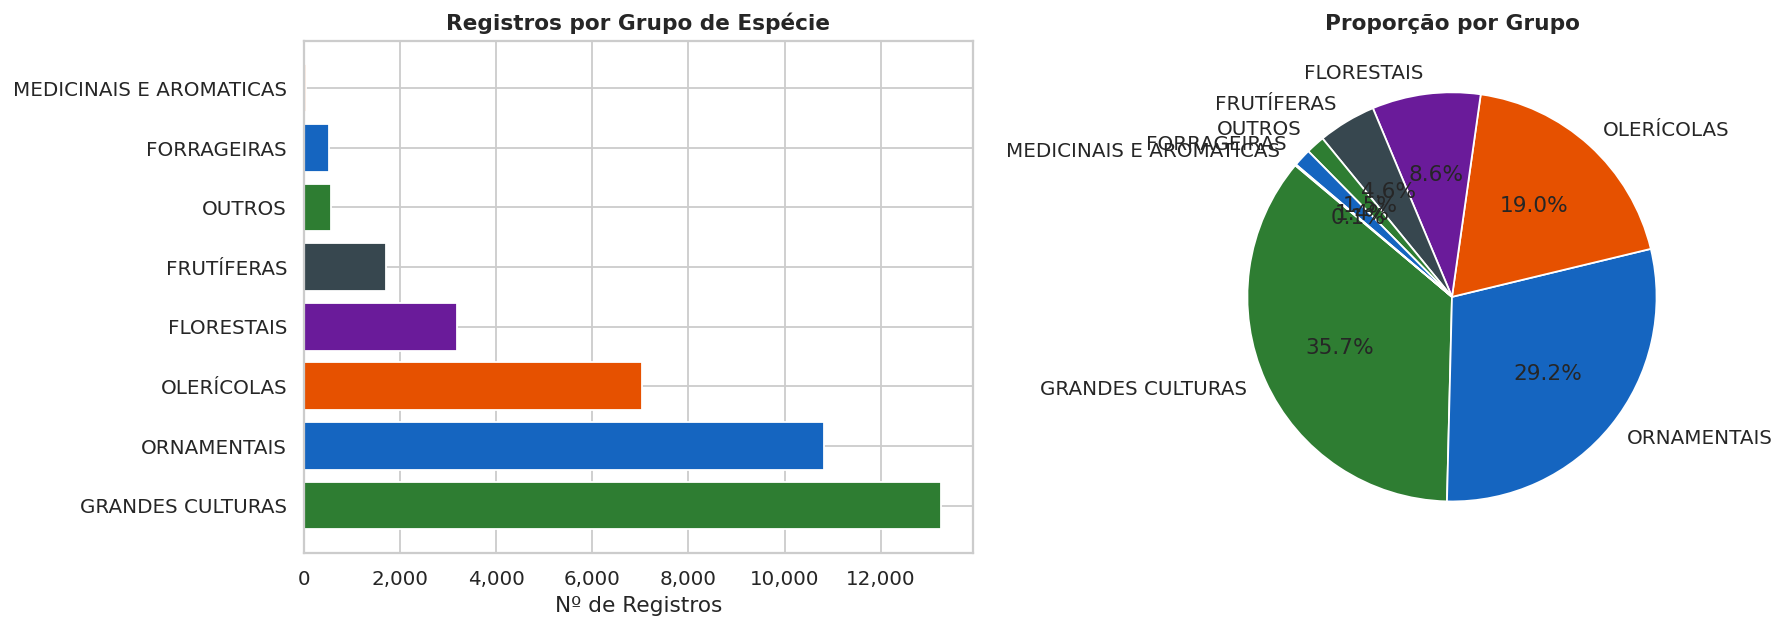

,GRUPO DA ESPÉCIE,Registros
0,GRANDES CULTURAS,13253
1,ORNAMENTAIS,10819
2,OLERÍCOLAS,7043
3,FLORESTAIS,3177
4,FRUTÍFERAS,1702
5,OUTROS,551
6,FORRAGEIRAS,524
7,MEDICINAIS E AROMATICAS,32


In [5]:
COL_GRUPO = 'GRUPO DA ESPÉCIE'

grupos = (
    df.groupby(COL_GRUPO)
    .size()
    .sort_values(ascending=False)
    .reset_index(name='Registros')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#2E7D32', '#1565C0', '#E65100', '#6A1B9A', '#37474F']
axes[0].barh(grupos[COL_GRUPO], grupos['Registros'], color=cores[:len(grupos)])
axes[0].set_title('Registros por Grupo de Espécie', fontweight='bold')
axes[0].set_xlabel('Nº de Registros')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(
    grupos['Registros'], labels=grupos[COL_GRUPO],
    autopct='%1.1f%%', colors=cores[:len(grupos)], startangle=140)
axes[1].set_title('Proporção por Grupo', fontweight='bold')

plt.tight_layout()
plt.show()
display(grupos.style.background_gradient(subset=['Registros'], cmap='Greens'))

---
---
## 6. Crescimento Anual de Registros <a id='6-crescimento-anual'></a>

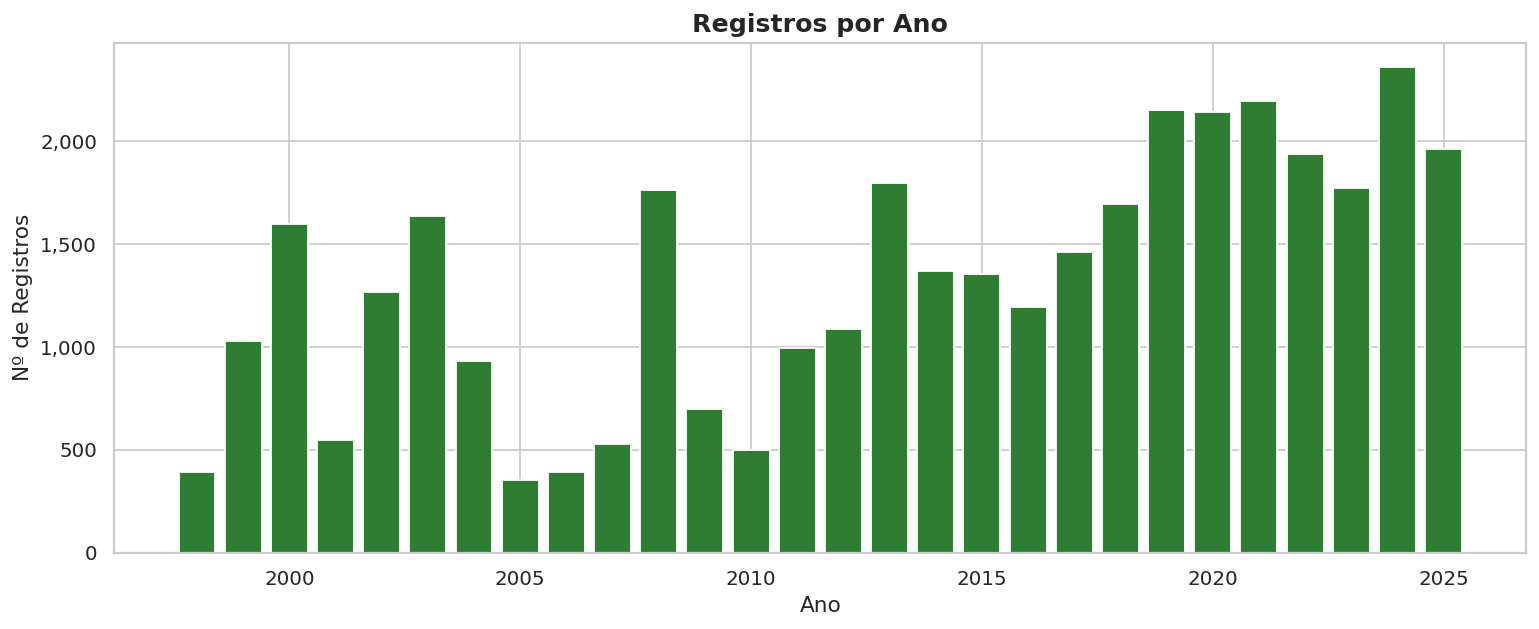

In [6]:
reg_ano = (
    df.groupby('ANO')
    .size()
    .reset_index(name='Registros')
    .set_index('ANO')
)
fig, ax = plt.subplots()
ax.bar(reg_ano.index.astype(int), reg_ano['Registros'], color='#2E7D32')
ax.set_title('Registros por Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 7. Evolução Anual por Grupo de Espécie <a id='7-evolucao-grupos'></a>

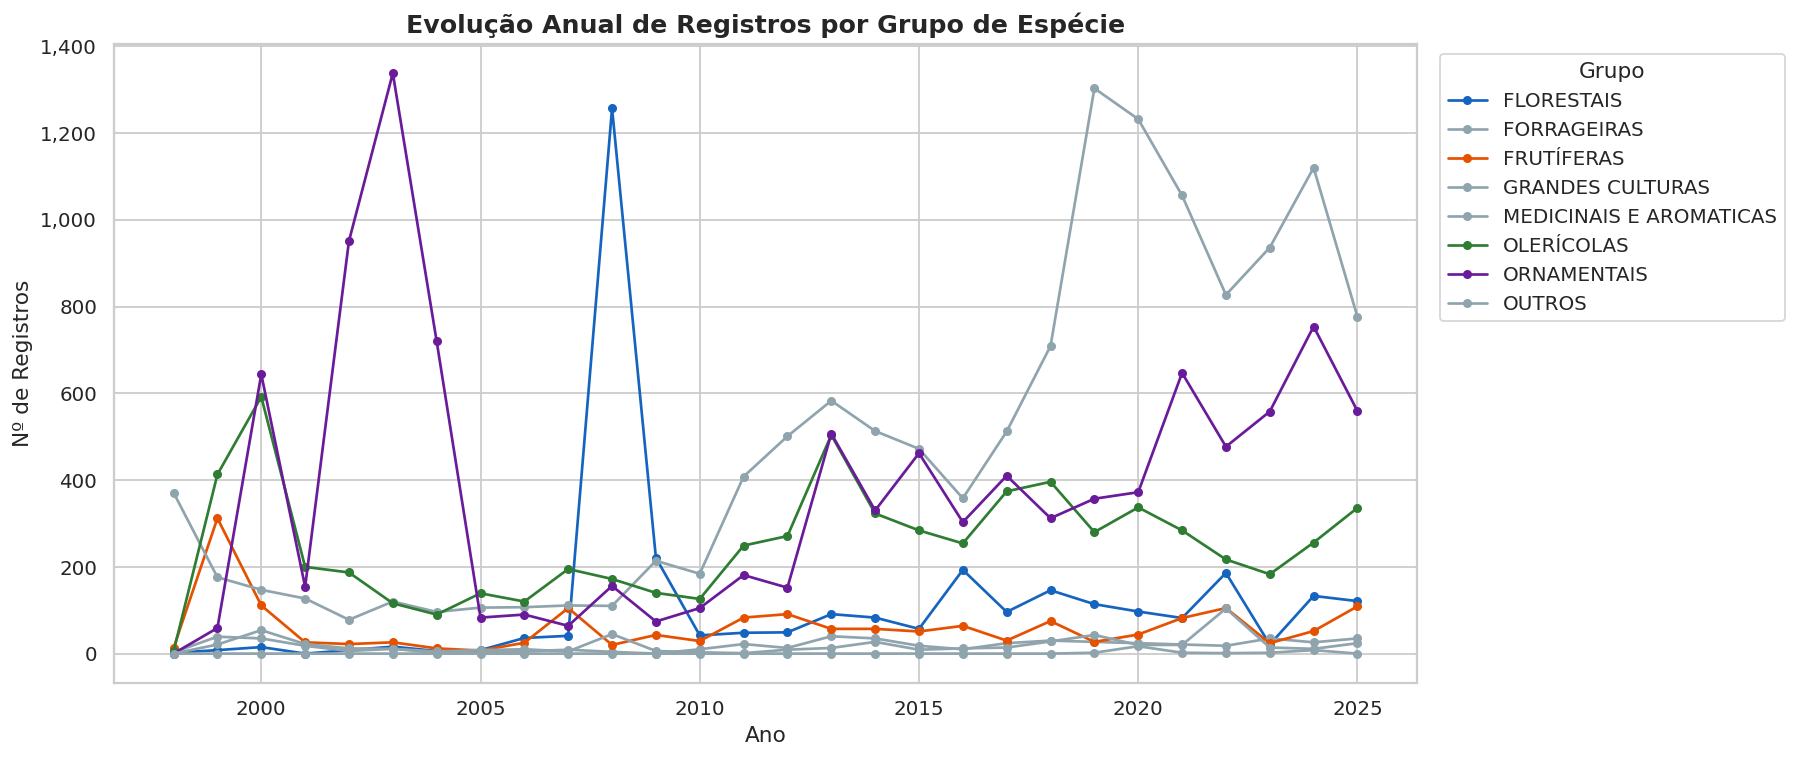

In [7]:
COL_GRUPO = 'GRUPO DA ESPÉCIE'

grupo_ano = (
    df.groupby(['ANO', COL_GRUPO])
    .size()
    .unstack(fill_value=0)
)

cores_grupos = {
    'OLERÍCOLAS':  '#2E7D32',
    'FRUTÍFERAS':  '#E65100',
    'FLORESTAIS':  '#1565C0',
    'ORNAMENTAIS': '#6A1B9A',
    'Outros':      '#546E7A',
}

fig, ax = plt.subplots(figsize=(14, 6))
for col in grupo_ano.columns:
    cor = cores_grupos.get(col, '#90A4AE')
    ax.plot(grupo_ano.index.astype(int), grupo_ano[col],
            marker='o', ms=4, label=col, color=cor)

ax.set_title('Evolução Anual de Registros por Grupo de Espécie',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Registros')
ax.legend(title='Grupo', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 8. Adoção do Nº de Formulário ao Longo do Tempo <a id='8-formulario-ano'></a>

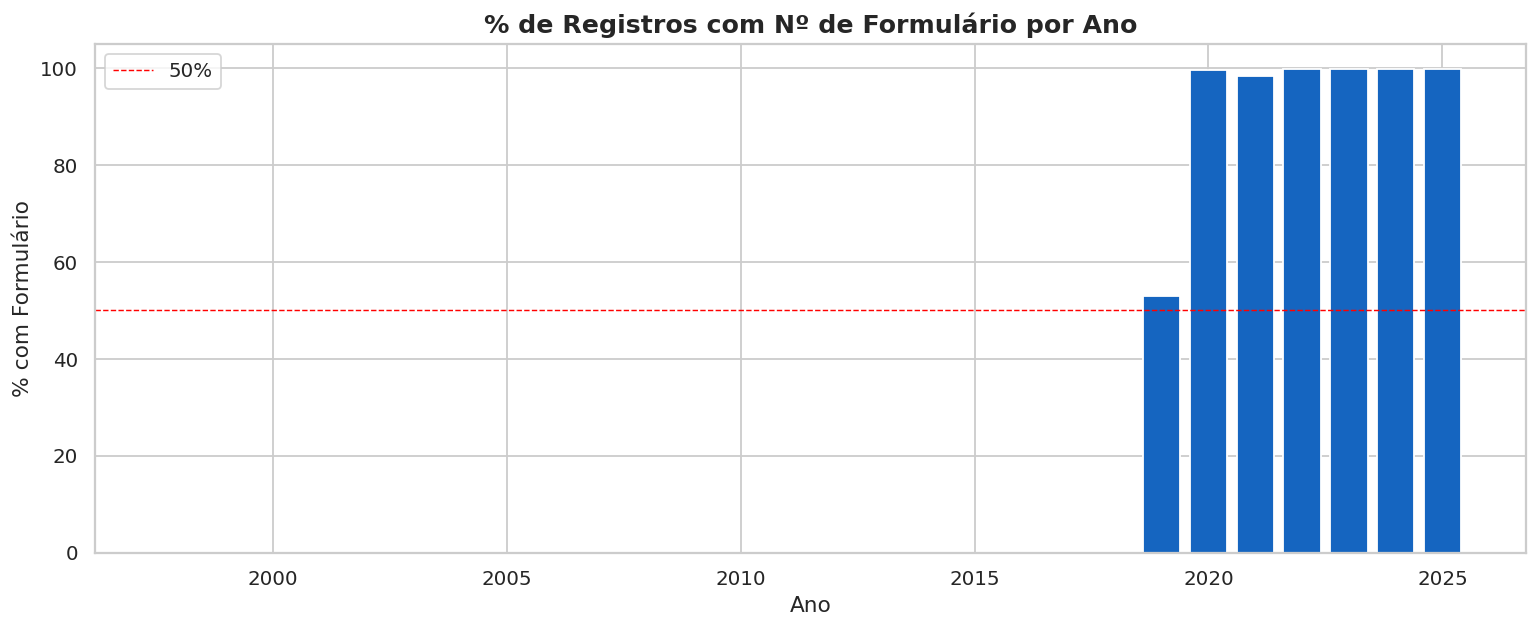


📋 Primeiro ano com ≥ 99,9% de formulários preenchidos: 2022


In [8]:
taxa_form = (
    df.groupby('ANO')
    .apply(lambda x: x[COL_FORMULARIO].notna().mean() * 100)
    .reset_index(name='% com Formulário')
)

fig, ax = plt.subplots()
ax.bar(taxa_form['ANO'].astype(int), taxa_form['% com Formulário'], color='#1565C0')
ax.set_title('% de Registros com Nº de Formulário por Ano',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% com Formulário')
ax.set_ylim(0, 105)
ax.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

primeiro_100 = taxa_form[taxa_form['% com Formulário'] >= 99.9]['ANO'].min()
print(f'\n📋 Primeiro ano com ≥ 99,9% de formulários preenchidos: {primeiro_100}')

---
---
## 9. Classificação de Mantenedores por Setor <a id='9-setores'></a>

In [9]:
dist = df['SETOR'].value_counts().to_frame()
display(dist.style.background_gradient(cmap='Blues'))

,count
SETOR,
Privado,29639
Nulo,3669
Público,3648
Misto,145


---
---
## 10. Setor Público — Detalhamento <a id='10-publico'></a>

In [10]:
df_pub = df[df['SETOR'] == 'Público'].copy()
top_pub = df_pub[COL_MANTENEDOR].value_counts().head(20).reset_index()
top_pub.index = range(1, 21)
display(top_pub.style.background_gradient(cmap='Blues'))

,MANTENEDOR (REQUERENTE) (NOME),count
1,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,1851
2,INSTITUTO AGRONÔMICO - IAC,695
3,INSTITUTO DE DESENVOLVIMENTO RURAL DO PARANÁ - IAPAR-EMATER,202
4,EMPRESA DE PESQUISA AGROPECUÁRIA E EXTENSÃO RURAL DE SANTA CATARINA - EPAGRI,183
5,EMPRESA DE PESQUISA AGROPECUÁRIA DE MINAS GERAIS - EPAMIG,122
6,UNIVERSIDADE ESTADUAL DO NORTE FLUMINENSE DARCY RIBEIRO - UENF,55
7,UNIVERSIDADE FEDERAL DE VIÇOSA-UFV,53
8,INSTITUTO MATO-GROSSENSE DO ALGODÃO - IMAMT,50
9,UNIVERSIDADE FEDERAL DE UBERLÂNDIA-UFU,35
10,Universidade do Estado do Mato Grosso - UNEMAT,31


---
---
## 11. Setor Misto — Detalhamento <a id='11-misto'></a>

In [11]:
display(
    df[df['SETOR'] == 'Misto'][COL_MANTENEDOR]
    .value_counts()
    .head(20)
    .reset_index()
    .style.background_gradient(cmap='YlOrBr')
)

,MANTENEDOR (REQUERENTE) (NOME),count
0,FUNDAÇÃO DE APOIO À TECNOLOGIA CAFEEIRA- FUNDAÇÃO PROCAFÉ,47
1,COOPERATIVA VINICOLA GARIBALDI LTDA,24
2,FUNDAÇÃO DE APOIO À PESQUISA AGROPECUÁRIA DE MATO GROSSO - FUNDAÇÃO MT,23
3,FUNDAÇÃO PRÓ-SEMENTES DE APOIO À PESQUISA,12
4,FUNDAÇÃO AGRÁRIA DE PESQUISA AGROPECUÁRIA - FAPA,8
5,COOPERATIVA VEILING HOLAMBRA,8
6,COOPERATIVA AGROECOLÓGICA NACIONAL TERRA E VIDA LTDA - COONATERRA,6
7,FUNDAÇÃO MS PARA PESQUISA E DIFUSÃO DE TECNOLOGIAS,4
8,COOPERATIVA AGRÁRIA AGROINDUSTRIAL,4
9,"Fundação de Integração, Desenvolvimento e Educação do Noroeste do Estado do Rio Grande do Sul",3


---
## 12. Mantenedores Estrangeiros vs. Nacionais <a id='12-estrangeiros'></a>

,Registros,% do Total
ORIGEM,,
Nacional,23303,62.800000
Estrangeiro,10129,27.300000
Nulo,3669,9.900000


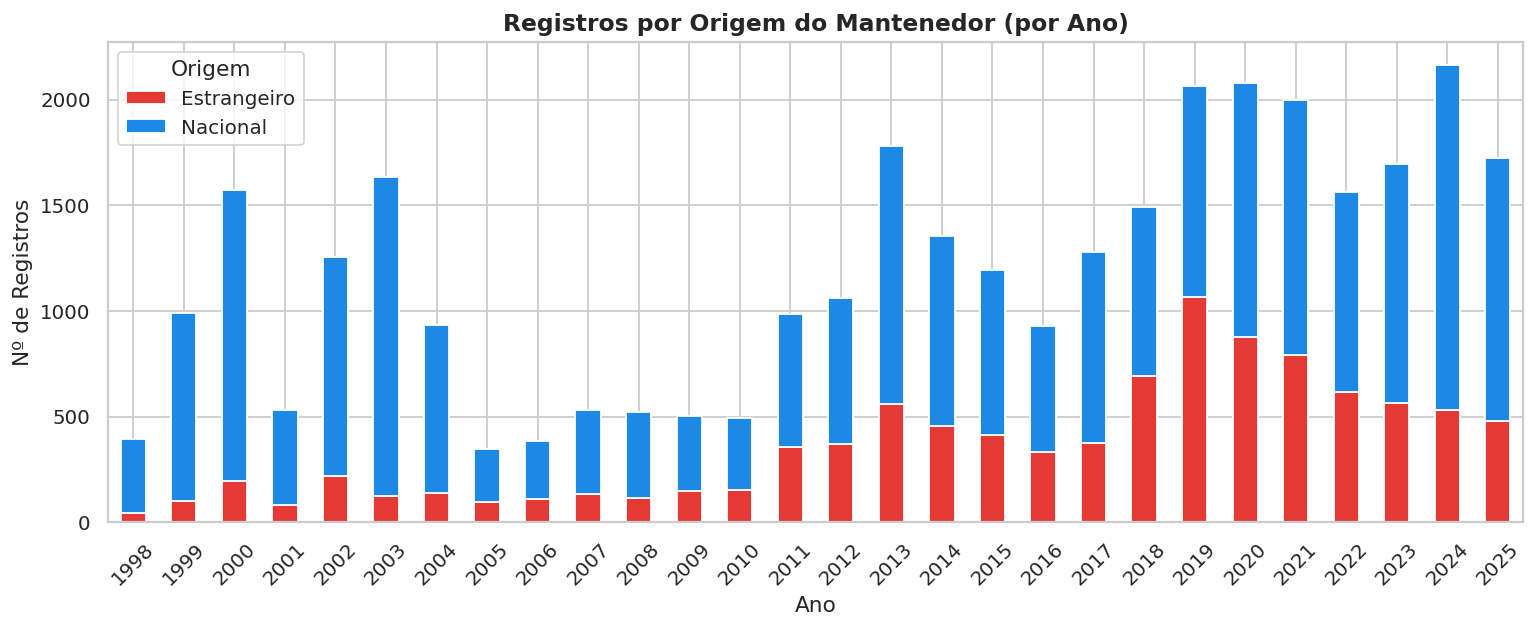

In [12]:
KW_ESTRANGEIROS = [
    'syngenta', 'monsanto', 'bayer', 'corteva', 'pioneer',
    'sakata', 'takii', 'vilmorin', 'ball horticultura', 'enza zaden',
    'hm. clause', 'limagrain', 'rijk zwaan', 'east-west seed',
    'longping', 'basf', 'nunhems', 'green market', 'yuksel',
]

def classif_origem(nome):
    if pd.isna(nome): return 'Nulo'
    n = nome.lower()
    for kw in KW_ESTRANGEIROS:
        if kw in n: return 'Estrangeiro'
    return 'Nacional'

df['ORIGEM'] = df[COL_MANTENEDOR].apply(classif_origem)

dist_orig = df['ORIGEM'].value_counts().to_frame('Registros')
dist_orig['% do Total'] = (dist_orig / dist_orig.sum() * 100).round(1)
display(dist_orig.style.background_gradient(subset=['Registros'], cmap='Blues'))

# Evolução temporal
orig_ano = (
    df[df['ORIGEM'] != 'Nulo']
    .groupby(['ANO', 'ORIGEM'])
    .size().unstack(fill_value=0)
)

fig, ax = plt.subplots()
orig_ano.plot(kind='bar', stacked=True, ax=ax,
              color={'Estrangeiro': '#E53935', 'Nacional': '#1E88E5'})
ax.set_title('Registros por Origem do Mantenedor (por Ano)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Registros')
ax.legend(title='Origem')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 13. Composição dos Grupos por Setor <a id='13-grupos-setor'></a>

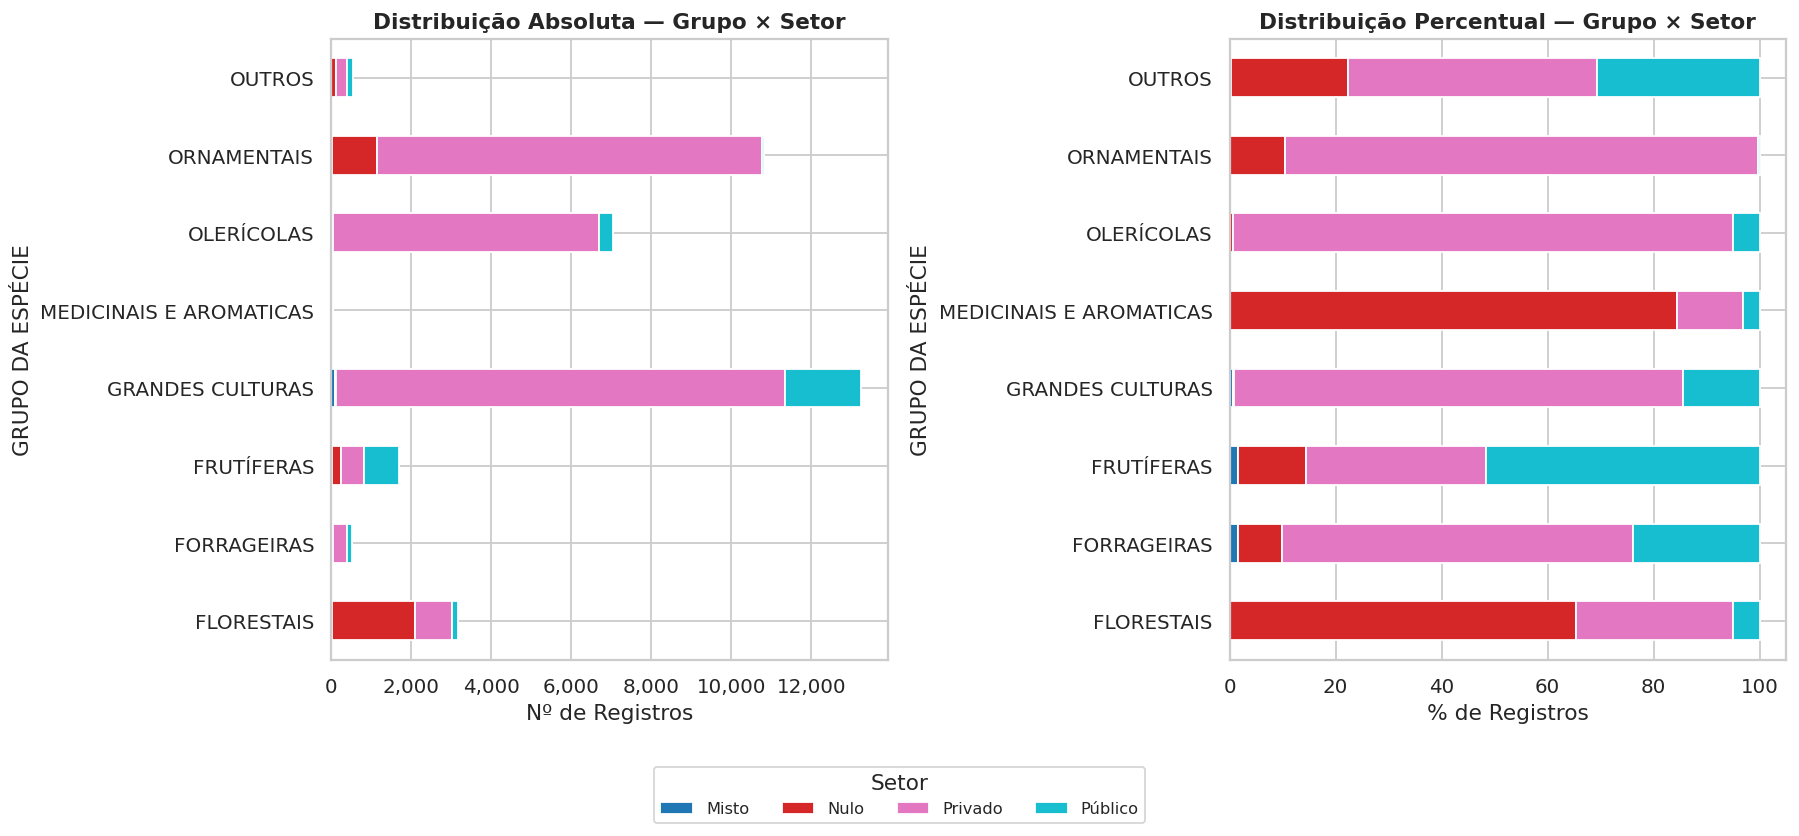


📊 Tabela percentual por grupo e setor:


SETOR,Misto,Nulo,Privado,Público
GRUPO DA ESPÉCIE,,,,
FLORESTAIS,0.100000,65.300000,29.500000,5.100000
FORRAGEIRAS,1.500000,8.400000,66.200000,23.900000
FRUTÍFERAS,1.500000,12.900000,34.000000,51.600000
GRANDES CULTURAS,0.700000,0.100000,84.700000,14.500000
MEDICINAIS E AROMATICAS,0.000000,84.400000,12.500000,3.100000
OLERÍCOLAS,0.100000,0.500000,94.400000,5.000000
ORNAMENTAIS,0.000000,10.500000,89.100000,0.400000
OUTROS,0.200000,22.100000,47.000000,30.700000


In [13]:
COL_GRUPO = 'GRUPO DA ESPÉCIE'

pivot     = pd.crosstab(df[COL_GRUPO], df['SETOR'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── gráfico absoluto ──────────────────────────────────────────────────────
pivot.plot(kind='barh', stacked=True, ax=axes[0], colormap='tab10',
           legend=False)
axes[0].set_title('Distribuição Absoluta — Grupo × Setor', fontweight='bold')
axes[0].set_xlabel('Nº de Registros')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── gráfico percentual ────────────────────────────────────────────────────
pivot_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10',
               legend=False)
axes[1].set_title('Distribuição Percentual — Grupo × Setor', fontweight='bold')
axes[1].set_xlabel('% de Registros')

# ── legenda única abaixo da figura ────────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title='Setor',
           loc='lower center',
           bbox_to_anchor=(0.5, -0.08),
           ncol=len(labels),
           frameon=True,
           fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()

print('\n📊 Tabela percentual por grupo e setor:')
display(pivot_pct.style.background_gradient(cmap='Blues'))

---
## 14. Registros sem Cultivar Nomeada <a id='14-sem-cultivar'></a>

Total sem cultivar nomeada: 3,570 (9.6%)


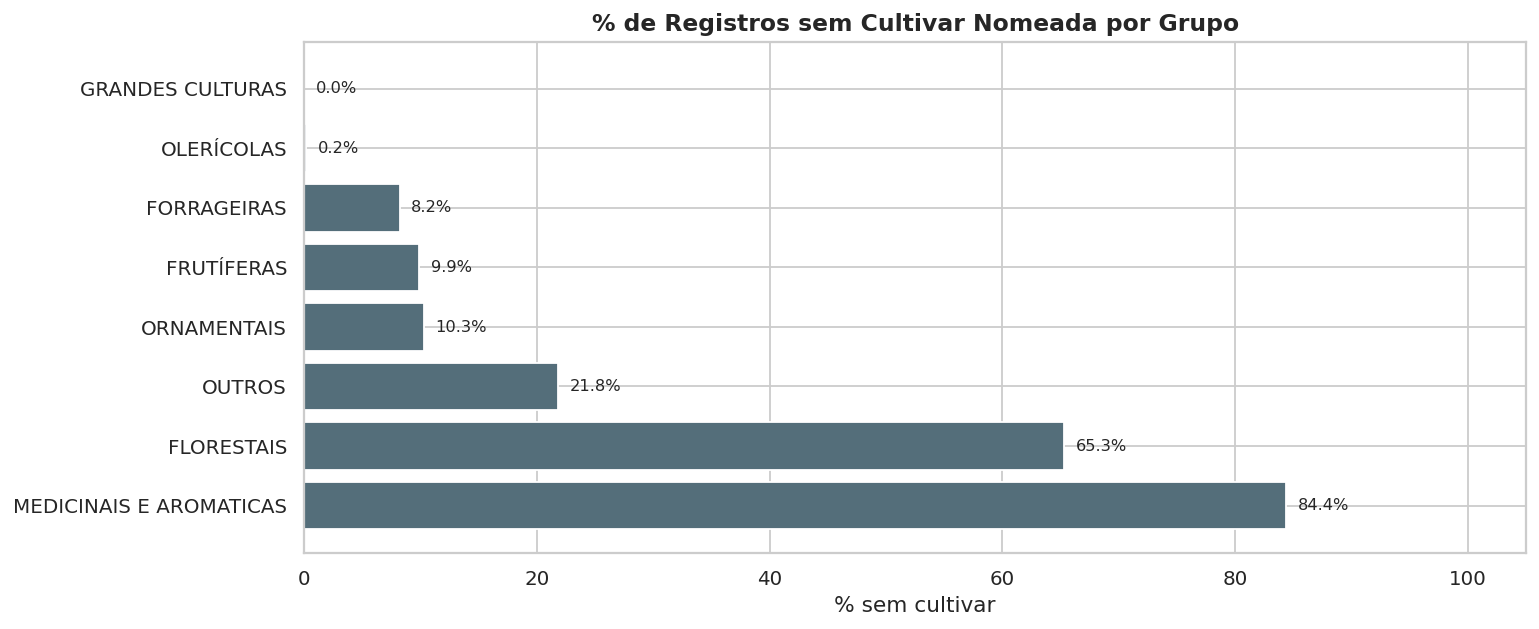

,GRUPO DA ESPÉCIE,Sem Nome,Total,% Sem Nome
0,MEDICINAIS E AROMATICAS,27,32,84.400000
1,FLORESTAIS,2076,3177,65.300000
2,OUTROS,120,551,21.800000
3,ORNAMENTAIS,1119,10819,10.300000
4,FRUTÍFERAS,168,1702,9.900000
5,FORRAGEIRAS,43,524,8.200000
6,OLERÍCOLAS,16,7043,0.200000
7,GRANDES CULTURAS,1,13253,0.000000


In [14]:
COL_GRUPO = 'GRUPO DA ESPÉCIE'

sem_nome = df[df[COL_CULTIVAR].isna()].copy()
print(f'Total sem cultivar nomeada: {len(sem_nome):,} ({len(sem_nome)/len(df)*100:.1f}%)')

sem_grupo = sem_nome[COL_GRUPO].value_counts().reset_index()
sem_grupo.columns = [COL_GRUPO, 'Sem Nome']

total_grupo = df[COL_GRUPO].value_counts().reset_index()
total_grupo.columns = [COL_GRUPO, 'Total']

merge = sem_grupo.merge(total_grupo, on=COL_GRUPO)
merge['% Sem Nome'] = (merge['Sem Nome'] / merge['Total'] * 100).round(1)
merge = merge.sort_values('% Sem Nome', ascending=False)

fig, ax = plt.subplots()
ax.barh(merge[COL_GRUPO], merge['% Sem Nome'], color='#546E7A')
ax.set_title('% de Registros sem Cultivar Nomeada por Grupo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% sem cultivar')
ax.set_xlim(0, 105)
for i, v in enumerate(merge['% Sem Nome']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

display(merge.reset_index(drop=True).style.background_gradient(
    subset=['% Sem Nome'], cmap='Greys'))

---
## 15. Diversidade de Espécies por Mantenedor <a id='15-diversidade'></a>

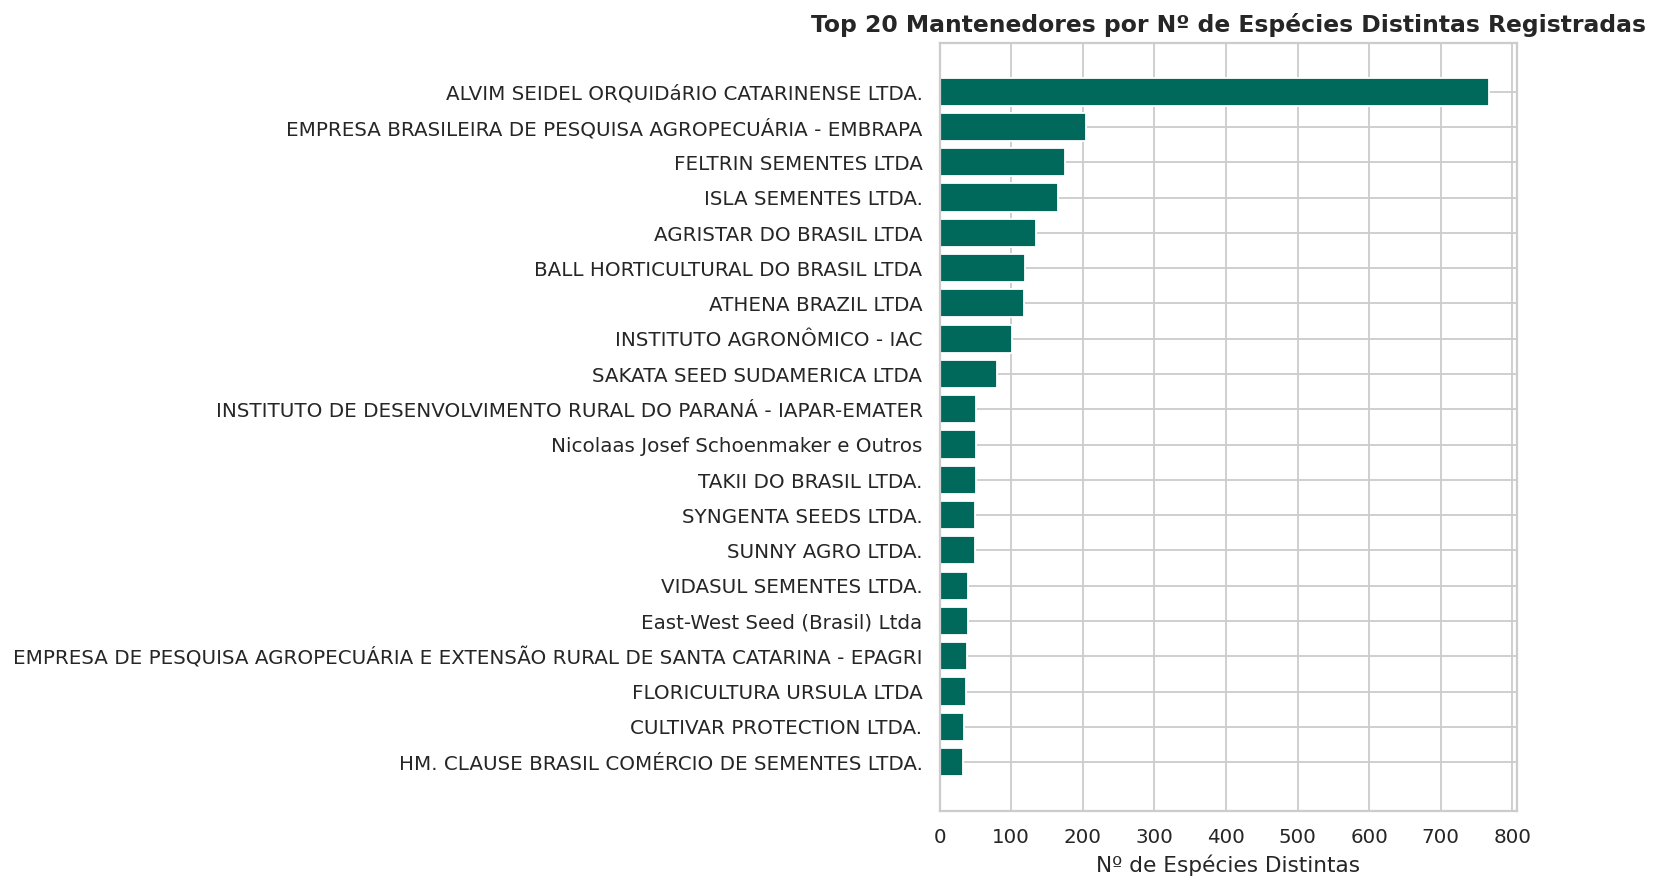

,MANTENEDOR (REQUERENTE) (NOME),Cultivares,Especies_Distintas,Media_por_Especie
1,ALVIM SEIDEL ORQUIDáRIO CATARINENSE LTDA.,770,768,1.000000
2,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,1851,205,9.000000
3,FELTRIN SEMENTES LTDA,1187,175,6.800000
4,ISLA SEMENTES LTDA.,697,166,4.200000
5,AGRISTAR DO BRASIL LTDA,1170,135,8.700000
6,BALL HORTICULTURAL DO BRASIL LTDA,1229,119,10.300000
7,ATHENA BRAZIL LTDA,588,118,5.000000
8,INSTITUTO AGRONÔMICO - IAC,695,101,6.900000
9,SAKATA SEED SUDAMERICA LTDA,1707,80,21.300000
10,INSTITUTO DE DESENVOLVIMENTO RURAL DO PARANÁ - IAPAR-EMATER,202,51,4.000000


In [15]:
top_div = (
    df.dropna(subset=[COL_MANTENEDOR])
    .groupby(COL_MANTENEDOR)
    .agg(
        Cultivares=('NOME CIENTÍFICO', 'count'),
        Especies_Distintas=('NOME CIENTÍFICO', 'nunique'),
    )
    .query('Cultivares >= 50')
    .assign(Media_por_Especie=lambda d: (d.Cultivares / d.Especies_Distintas).round(1))
    .sort_values('Especies_Distintas', ascending=False)
    .head(20)
    .reset_index()
)
top_div.index = range(1, len(top_div) + 1)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_div[COL_MANTENEDOR], top_div['Especies_Distintas'], color='#00695C')
ax.set_title('Top 20 Mantenedores por Nº de Espécies Distintas Registradas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de Espécies Distintas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(top_div.style.background_gradient(
    subset=['Especies_Distintas', 'Cultivares'], cmap='YlGn'))

---
---
## 16. Líderes: Soja e Milho <a id='16-soja-milho'></a>

In [16]:
top5_soja = (
    df[df[COL_NOME_COM].str.upper().str.contains('SOJA', na=False)]
    [COL_MANTENEDOR].value_counts().head(5).reset_index()
)
top5_soja.columns = ['Mantenedor Soja', 'Registros']
top5_soja.index = range(1, 6)

top5_milho = (
    df[df[COL_NOME_COM].str.upper().str.contains('MILHO', na=False)]
    [COL_MANTENEDOR].value_counts().head(5).reset_index()
)
top5_milho.columns = ['Mantenedor Milho', 'Registros']
top5_milho.index = range(1, 6)

print('🟢 TOP 5 MANTENEDORES DE SOJA')
display(top5_soja.style.background_gradient(cmap='Greens'))
print('\n🟡 TOP 5 MANTENEDORES DE MILHO')
display(top5_milho.style.background_gradient(cmap='Oranges'))

🟢 TOP 5 MANTENEDORES DE SOJA


,Mantenedor Soja,Registros
1,GDM GENÉTICA DO BRASIL S.A.,702
2,SYNGENTA SEEDS LTDA.,576
3,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,331
4,TMG TROPICAL MELHORAMENTO E GENETICA S.A.,174
5,D&PL BRASIL LTDA.,131



🟡 TOP 5 MANTENEDORES DE MILHO


,Mantenedor Milho,Registros
1,CORTEVA AGRISCIENCE DO BRASIL LTDA.,1717
2,MONSANTO DO BRASIL LTDA.,1360
3,SYNGENTA SEEDS LTDA.,748
4,LONGPING HIGH-TECH BIOTECNOLOGIA LTDA.,403
5,GDM GENÉTICA DO BRASIL S.A.,164


---
---
## 17. Mantenedores nas Cultivares Mais Comuns <a id='17-lideres'></a>

In [17]:
pop_30  = df[COL_NOME_COM].value_counts().head(30).index
t_mant  = (
    df[df[COL_NOME_COM].isin(pop_30)][COL_MANTENEDOR]
    .value_counts().head(20).reset_index()
)
t_mant.index = range(1, 21)
display(t_mant.style.background_gradient(cmap='Purples'))

,MANTENEDOR (REQUERENTE) (NOME),count
1,CORTEVA AGRISCIENCE DO BRASIL LTDA.,1917
2,SYNGENTA SEEDS LTDA.,1483
3,MONSANTO DO BRASIL LTDA.,1386
4,SAKATA SEED SUDAMERICA LTDA,1168
5,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,1063
6,GDM GENÉTICA DO BRASIL S.A.,1008
7,KARÍS COMÉRCIO DE INSUMOS AGRÍCOLAS LTDA,1004
8,Nicolaas Josef Schoenmaker e Outros,917
9,AGRISTAR DO BRASIL LTDA,642
10,ALVIM SEIDEL ORQUIDáRIO CATARINENSE LTDA.,626


---
## 18. Concentração de Mercado por Espécie <a id='18-concentracao'></a>

Para os 10 nomes comuns mais registrados, calcula qual fatia (%) os 3 maiores mantenedores detêm.

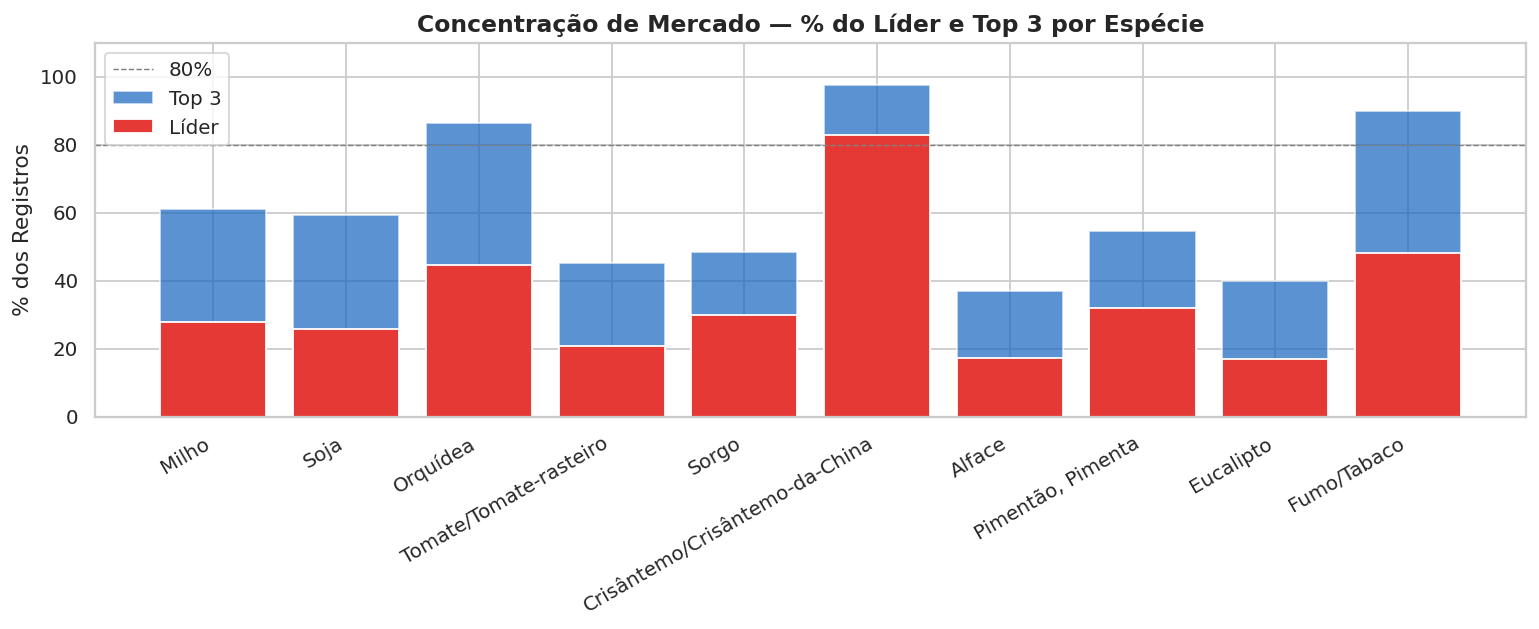

,Total Registros,Líder,% Líder,% Top 3
Espécie,,,,
Milho,6179,CORTEVA AGRISCIENCE DO BRASIL LTDA.,27.800000,61.000000
Soja,2719,GDM GENÉTICA DO BRASIL S.A.,25.800000,59.200000
Orquídea,1577,KARÍS COMÉRCIO DE INSUMOS AGRÍCOLAS LTDA,44.600000,86.400000
Tomate/Tomate-rasteiro,1394,SAKATA SEED SUDAMERICA LTDA,20.700000,45.100000
Sorgo,1228,INNOVATIVE SEED SOLUTIONS BRASIL - SEMENTES INOVADORAS LTDA,29.800000,48.500000
Crisântemo/Crisântemo-da-China,869,Nicolaas Josef Schoenmaker e Outros,82.700000,97.400000
Alface,673,AGRISTAR DO BRASIL LTDA,17.200000,37.000000
"Pimentão, Pimenta",654,SAKATA SEED SUDAMERICA LTDA,32.100000,54.700000
Eucalipto,596,SYLVAMO DO BRASIL LTDA.,16.900000,39.900000


In [18]:
top10_esp = df[COL_NOME_COM].value_counts().head(10).index.tolist()

rows = []
for esp in top10_esp:
    sub   = df[(df[COL_NOME_COM] == esp) & df[COL_MANTENEDOR].notna()]
    total = len(sub)
    top3  = sub[COL_MANTENEDOR].value_counts().head(3)
    rows.append({
        'Espécie':         esp,
        'Total Registros': total,
        'Líder':           top3.index[0] if len(top3) >= 1 else '-',
        '% Líder':         round(top3.iloc[0] / total * 100, 1) if len(top3) >= 1 else 0,
        '% Top 3':         round(top3.sum()   / total * 100, 1) if len(top3) >= 1 else 0,
    })

conc = pd.DataFrame(rows).set_index('Espécie')

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(conc))
ax.bar(x, conc['% Top 3'], label='Top 3', color='#1565C0', alpha=0.7)
ax.bar(x, conc['% Líder'], label='Líder',  color='#E53935')
ax.set_xticks(list(x))
ax.set_xticklabels(conc.index, rotation=30, ha='right')
ax.set_title('Concentração de Mercado — % do Líder e Top 3 por Espécie',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% dos Registros')
ax.set_ylim(0, 110)
ax.axhline(80, linestyle='--', color='gray', linewidth=0.8, label='80%')
ax.legend()
plt.tight_layout()
plt.show()

display(conc.style.background_gradient(
    subset=['% Líder', '% Top 3'], cmap='Reds'))

In [19]:
# Exibe o código-fonte das três funções centrais do pipeline:
# _download_csv  → faz POST no SNPC e salva o CSV localmente
# _limpar_coluna_texto → remove aspas redundantes, tags HTML, barras escapadas e vazios
# _limpar        → orquestra todas as conversões de tipo e limpeza do DataFrame
import inspect
import data_pipeline as dp
from IPython.display import display, Markdown

def show_source(fn, title):
    src = inspect.getsource(fn)
    display(Markdown(f'### `{title}`\n```python\n{src}\n```'))

show_source(dp._download_csv, '_download_csv')
show_source(dp._limpar_coluna_texto, '_limpar_coluna_texto')
show_source(dp._limpar, '_limpar')

### `_download_csv`
```python
def _download_csv(destino: Path, timeout: int = 180) -> None:
    log.info("⬇  Baixando CSV do SNPC/MAPA…")
    try:
        resp = requests.post(
            SNPC_URL,
            params=SNPC_QUERY,
            data=SNPC_DATA,
            headers=HEADERS,
            timeout=timeout,
            stream=True,
        )
        resp.raise_for_status()

        content_type = resp.headers.get("Content-Type", "")
        if "csv" not in content_type and "text" not in content_type:
            raise ValueError(
                f"Resposta inesperada do servidor (Content-Type: {content_type}). "
                "O site pode ter mudado de estrutura."
            )

        destino.write_bytes(resp.content)
        size_kb = destino.stat().st_size / 1024
        log.info("✅ CSV salvo em '%s' (%.1f KB)", destino.name, size_kb)

    except requests.exceptions.Timeout:
        raise TimeoutError(f"O download excedeu {timeout}s. Verifique sua conexão.")
    except requests.exceptions.RequestException as exc:
        raise RuntimeError(f"Falha ao baixar o CSV: {exc}") from exc

```

### `_limpar_coluna_texto`
```python
def _limpar_coluna_texto(serie: pd.Series) -> pd.Series:
    s = serie.copy()
    s = s.str.strip()
    s = s.str.replace(_RE_ASPAS_SIMPLES_ENVOLVENDO, r"\1", regex=True)
    s = s.str.replace(_RE_ASPAS_DUPLAS_ENVOLVENDO,  r"\1", regex=True)
    s = s.str.replace(_RE_HTML_TAGS, "", regex=True).str.strip()
    s = s.str.replace(_RE_BACKSLASH, "'", regex=True)
    s = s.replace("", np.nan)
    return s

```

### `_limpar`
```python
def _limpar(df: pd.DataFrame) -> pd.DataFrame:
    log.info("🧹 Iniciando limpeza dos dados…")

    colunas_texto = [COL_CULTIVAR, COL_NOME_COM, COL_NOME_CIEN, COL_GRUPO, COL_SITUACAO, COL_MANTENEDOR]
    for col in colunas_texto:
        if col in df.columns:
            df[col] = _limpar_coluna_texto(df[col])

    if COL_FORMULARIO in df.columns:
        df[COL_FORMULARIO] = (
            df[COL_FORMULARIO]
            .str.strip()
            .replace("", np.nan)
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
        )

    if COL_REGISTRO in df.columns:
        df[COL_REGISTRO] = pd.to_numeric(df[COL_REGISTRO], errors="coerce").astype("Int64")

    for col_data in [COL_DATA_REG, COL_DATA_VAL]:
        if col_data in df.columns:
            df[col_data] = pd.to_datetime(
                df[col_data].str.strip(),
                dayfirst=True,
                errors="coerce",
            )

    if COL_DATA_REG in df.columns:
        df["ANO"] = df[COL_DATA_REG].dt.year.astype("Int64")

    if COL_GRUPO in df.columns:
        df[COL_GRUPO] = df[COL_GRUPO].str.strip().str.upper()

    antes = len(df)
    df = df.drop_duplicates()
    removidas = antes - len(df)
    if removidas:
        log.warning("⚠️  %d linha(s) duplicada(s) removida(s).", removidas)

    log.info("✅ Limpeza concluída — %d registros | %d colunas", df.shape[0], df.shape[1])
    return df.reset_index(drop=True)

```

---
---
## 19. Nulos por Ano — Mantenedor <a id='19-nulos-ano'></a>

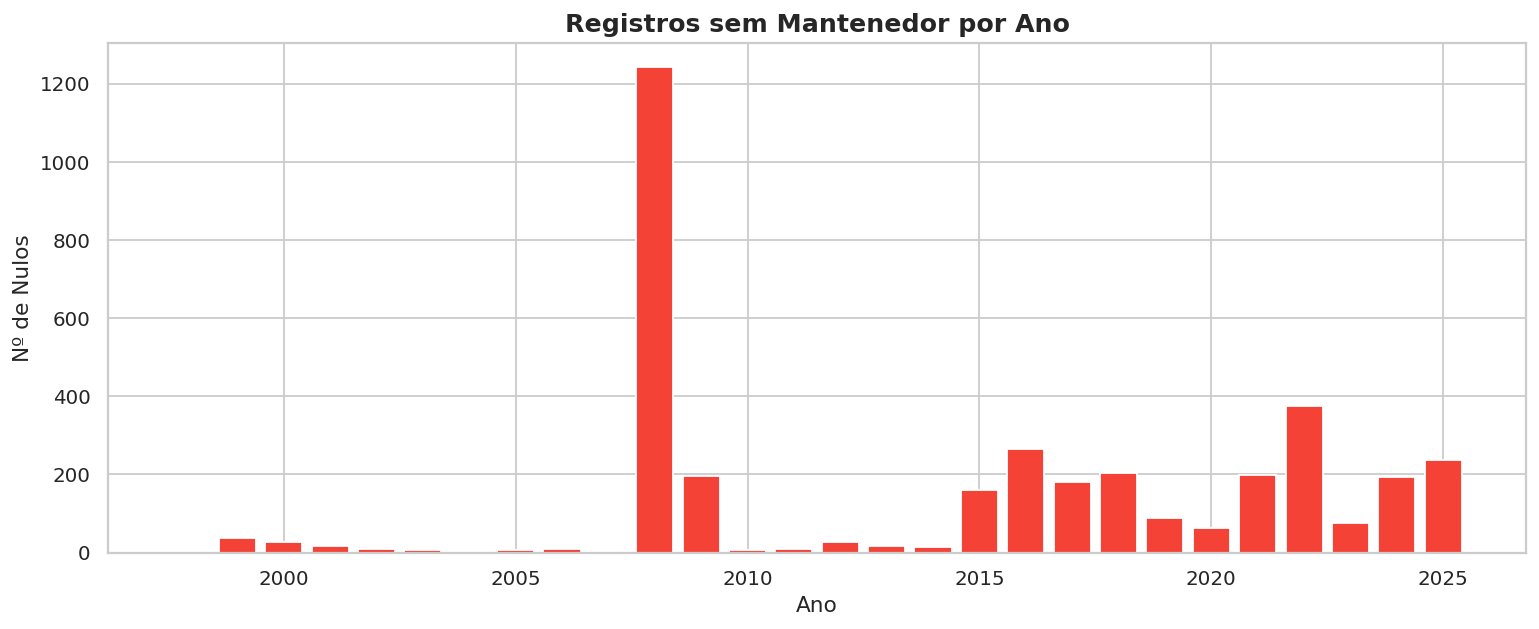

In [20]:
nl = df[df[COL_MANTENEDOR].isnull()].groupby('ANO').size()
fig, ax = plt.subplots()
ax.bar(nl.index.astype(int), nl.values, color='#F44336')
ax.set_title('Registros sem Mantenedor por Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Nulos')
plt.tight_layout()
plt.show()

---
## 20. Tempo entre Formulário e Registro <a id='20-tempo-registro'></a>

O número de formulário começa com o ano (ex: `202100123` → 2021). Calculamos quanto tempo decorreu até a emissão do certificado de registro.

📊 Tempo médio entre formulário e registro: 0.14 anos
📊 Mediana: 0.0 anos


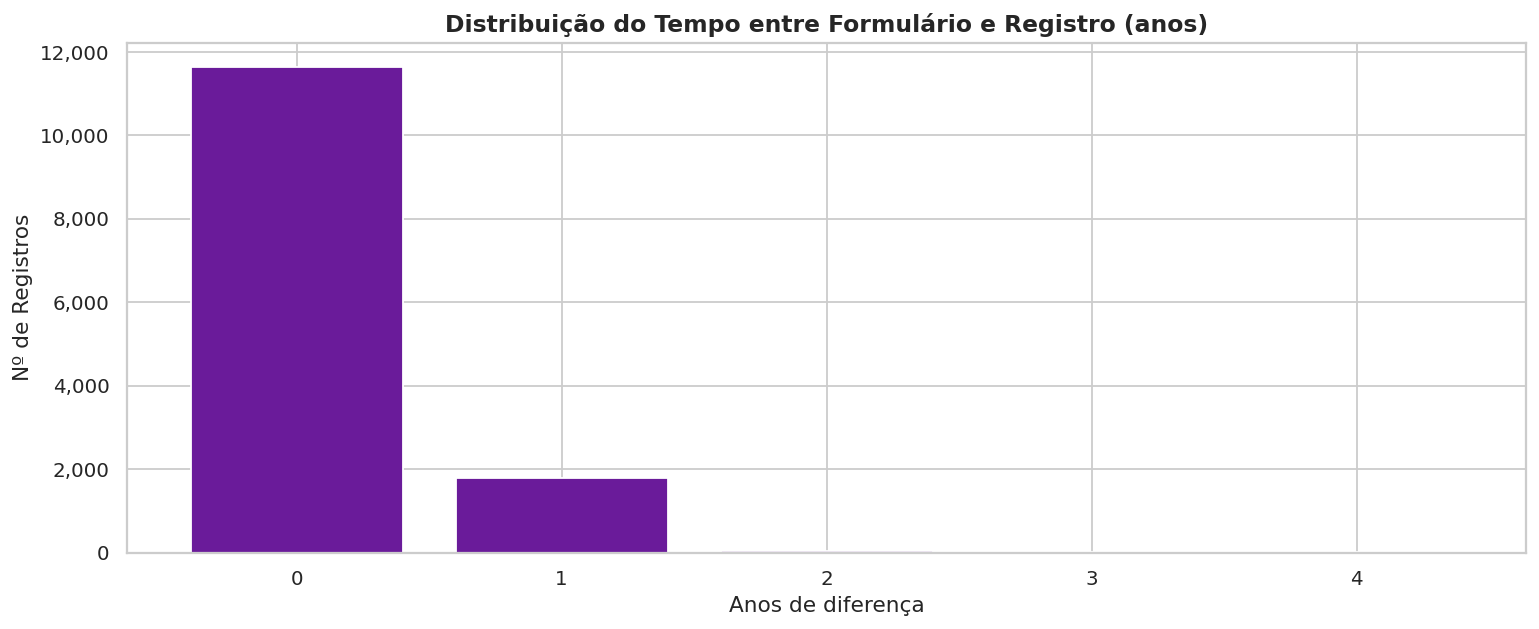

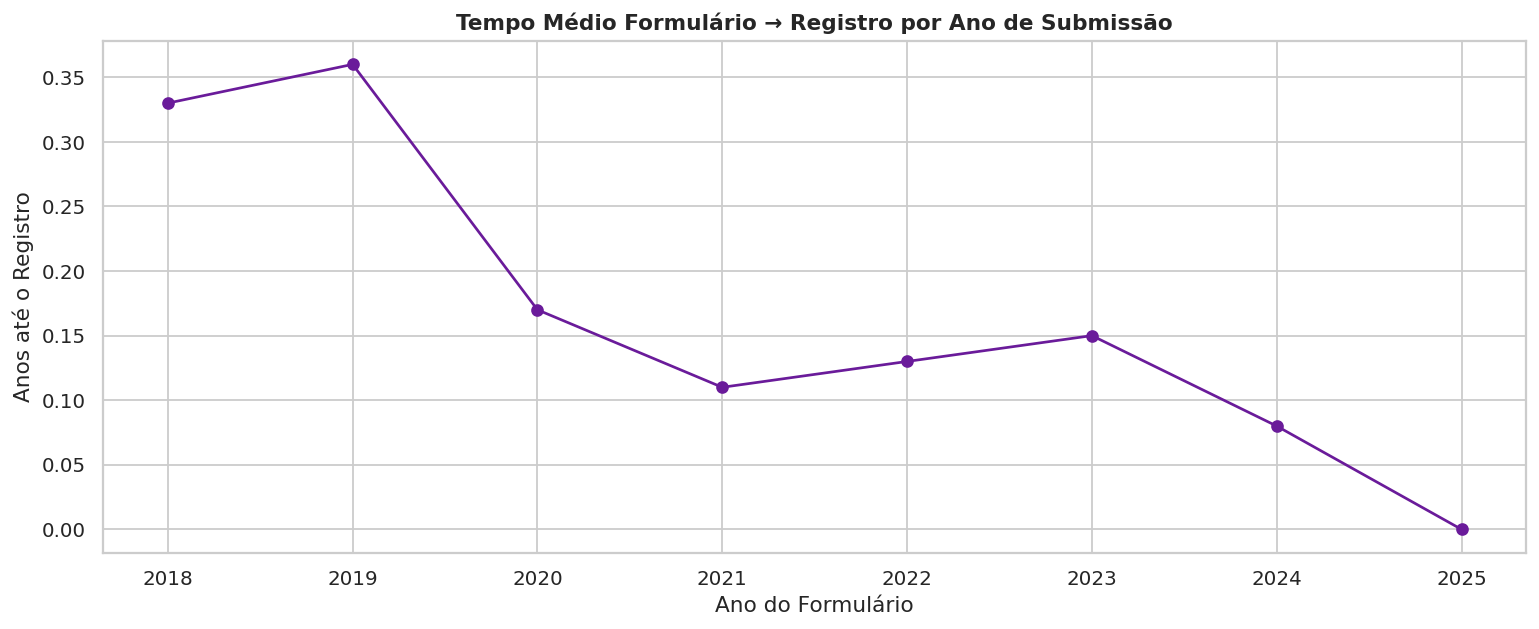

In [21]:
df_form = df[df[COL_FORMULARIO].notna()].copy()
df_form['ANO_FORM'] = (
    df_form[COL_FORMULARIO].astype(str).str[:4].astype(int)
)
df_form['DELTA_ANOS'] = df_form['ANO'] - df_form['ANO_FORM']
df_form = df_form[df_form['DELTA_ANOS'].between(0, 10)]

print('📊 Tempo médio entre formulário e registro:',
      round(df_form['DELTA_ANOS'].mean(), 2), 'anos')
print('📊 Mediana:', df_form['DELTA_ANOS'].median(), 'anos')

delta_counts = df_form['DELTA_ANOS'].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(delta_counts.index.astype(int), delta_counts.values, color='#6A1B9A')
ax.set_title('Distribuição do Tempo entre Formulário e Registro (anos)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Anos de diferença')
ax.set_ylabel('Nº de Registros')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Média por ano de submissão
media_delta = df_form.groupby('ANO_FORM')['DELTA_ANOS'].mean().round(2)
fig2, ax2 = plt.subplots()
ax2.plot(media_delta.index, media_delta.values, marker='o', color='#6A1B9A')
ax2.set_title('Tempo Médio Formulário → Registro por Ano de Submissão',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Ano do Formulário')
ax2.set_ylabel('Anos até o Registro')
plt.tight_layout()
plt.show()

---
## 21. Registros Expirados <a id='21-expirados'></a>

A validade padrão de um registro é de 15 anos. Verificamos quantos registros já passaram da data de validade.

✅ Vigentes:  37,020 (99.8%)
❌ Expirados: 81 (0.2%)


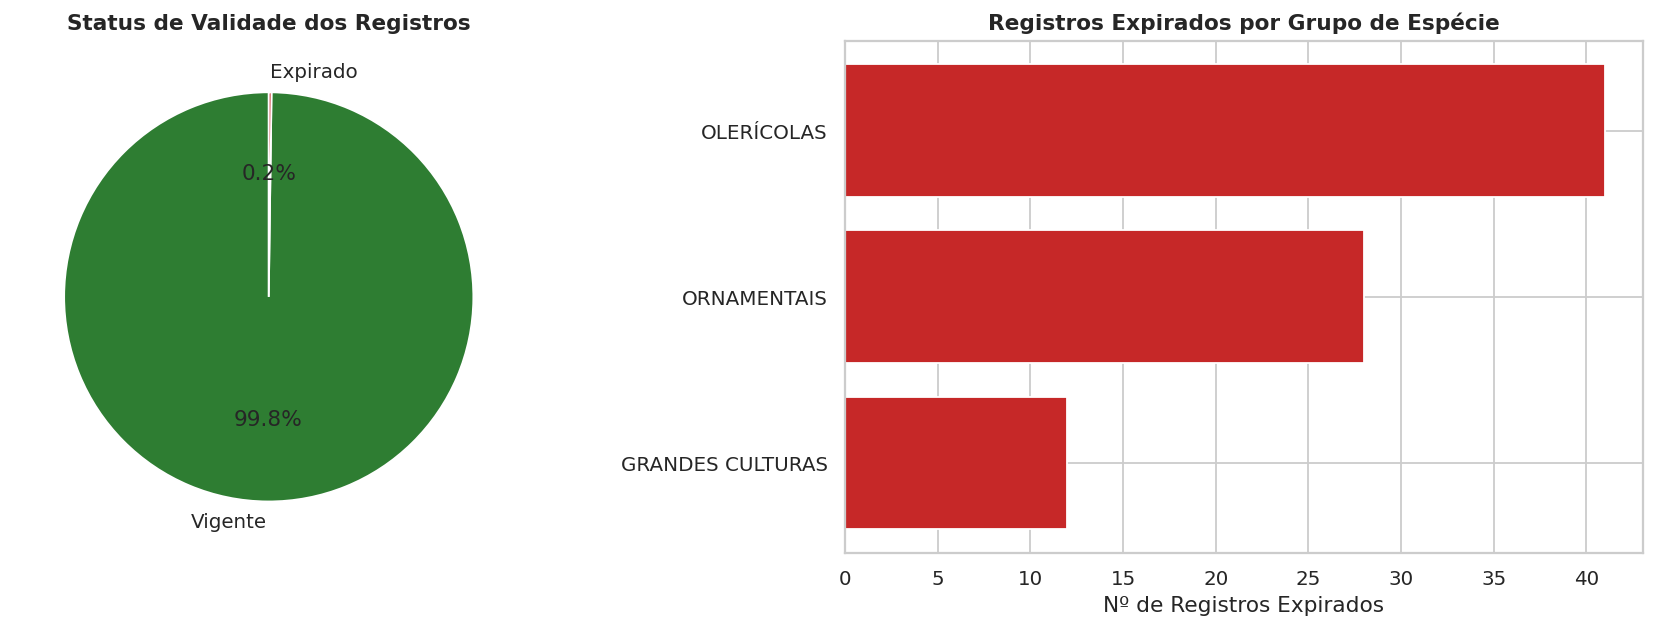


⏱ Duração típica: mediana=15 anos, mínimo=15.0, máximo=30.0


In [22]:
COL_DATA_VAL = 'DATA DE VALIDADE DO REGISTRO'
COL_DATA_REG = 'DATA DO REGISTRO'

hoje      = pd.Timestamp.now()
df['EXPIRADO'] = df[COL_DATA_VAL] < hoje

total     = len(df)
expirados = df['EXPIRADO'].sum()
vigentes  = total - expirados

print(f'✅ Vigentes:  {vigentes:,} ({vigentes/total*100:.1f}%)')
print(f'❌ Expirados: {expirados:,} ({expirados/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [vigentes, expirados],
    labels=['Vigente', 'Expirado'],
    autopct='%1.1f%%',
    colors=['#2E7D32', '#C62828'],
    startangle=90,
)
axes[0].set_title('Status de Validade dos Registros', fontweight='bold')

COL_GRUPO = 'GRUPO DA ESPÉCIE'
exp_grupo = (
    df[df['EXPIRADO']]
    .groupby(COL_GRUPO).size()
    .sort_values(ascending=True)
)
axes[1].barh(exp_grupo.index, exp_grupo.values, color='#C62828')
axes[1].set_title('Registros Expirados por Grupo de Espécie', fontweight='bold')
axes[1].set_xlabel('Nº de Registros Expirados')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

df['DURACAO_ANOS'] = (
    (df[COL_DATA_VAL] - df[COL_DATA_REG]).dt.days / 365.25
).round(1)
dur = df['DURACAO_ANOS'].dropna()
print(f'\n⏱ Duração típica: mediana={dur.median():.0f} anos,',
      f'mínimo={dur.min():.1f}, máximo={dur.max():.1f}')

## 🦆 DuckDB — Queries Analíticas SQL

Nesta seção, utilizamos o **DuckDB** para realizar consultas analíticas avançadas (OLAP) diretamente no *star schema* gerado a partir de nossos dados. O uso de SQL com funções de janelamento (*window functions*) e CTEs (*Common Table Expressions*) facilita agregações complexas.

In [ ]:
# 1. Setup: Conectando ao Banco de Dados
import duckdb
import pandas as pd
import db_manager

# Obter conexão com o banco DuckDB persistido em disco
conn = db_manager.get_conn(read_only=True)

### 1. Ranking de Mantenedores por Espécie (Top 3)
Utilização de `RANK()` over partition para identificar os principais mantenedores de cada espécie, filtrando apenas as espécies mais volumosas.

In [ ]:
# Window function para ranking de mantenedores
query_ranking = """
WITH MantenedoresEspecie AS (
    SELECT 
        e.nome_comum,
        m.nome AS mantenedor,
        COUNT(f.nr_registro) AS total_registros
    FROM fato_registro f
    JOIN dim_especie e ON f.id_especie = e.id_especie
    JOIN dim_mantenedor m ON f.id_mantenedor = m.id_mantenedor
    WHERE m.nome IS NOT NULL AND e.nome_comum IS NOT NULL
    GROUP BY e.nome_comum, m.nome
),
Ranking AS (
    SELECT 
        nome_comum, 
        mantenedor, 
        total_registros,
        RANK() OVER (PARTITION BY nome_comum ORDER BY total_registros DESC) as ranking
    FROM MantenedoresEspecie
)
SELECT *
FROM Ranking
WHERE ranking <= 3
ORDER BY nome_comum, ranking;
"""

# Exibindo uma amostra (apenas as primeiras 15 linhas para visualização)
conn.execute(query_ranking).fetchdf().head(15)

### 2. Índice Herfindahl-Hirschman (HHI) de Concentração por Espécie
O HHI é calculado utilizando `CTE`s para avaliar se o mercado de uma determinada cultivar de espécie é monopolizado (HHI próximo de 1) ou perfeitamente competitivo (HHI próximo a 0).

In [ ]:
# Cálculo de HHI para concentração de mercado (mercados monopolistas vs concorrenciais)
query_hhi = """
WITH shares AS (
    SELECT 
        e.nome_comum,
        m.nome,
        COUNT(*)::FLOAT / SUM(COUNT(*)) OVER (PARTITION BY e.nome_comum) AS share
    FROM fato_registro f
    JOIN dim_especie e USING (id_especie)
    JOIN dim_mantenedor m USING (id_mantenedor)
    WHERE m.nome IS NOT NULL AND e.nome_comum IS NOT NULL
    GROUP BY 1, 2
)
SELECT 
    nome_comum,
    ROUND(SUM(share * share)::NUMERIC, 4) AS hhi,
    COUNT(DISTINCT nome) as total_mantenedores
FROM shares
GROUP BY 1
-- Filtrar espécies com pelo menos 50 registros para evitar viés em amostras pequenas
HAVING SUM(share) > 0 AND total_mantenedores > 1
ORDER BY hhi DESC
LIMIT 15;
"""

conn.execute(query_hhi).fetchdf()

### 3. Variação Anual de Registros por Grupo (Crescimento YoY)
Uso da função condicional `LAG()` para calcular o crescimento (Year-over-Year).

In [ ]:
# Crescimento YoY (Year-over-Year) utilizando LAG()
query_yoy = """
WITH RegistrosAnuais AS (
    SELECT 
        t.ano,
        e.grupo,
        COUNT(f.nr_registro) AS total_registros
    FROM fato_registro f
    JOIN dim_tempo t ON f.id_data_reg = t.id_tempo
    JOIN dim_especie e ON f.id_especie = e.id_especie
    WHERE t.ano IS NOT NULL AND e.grupo IS NOT NULL
    GROUP BY t.ano, e.grupo
),
AnaliseCrescimento AS (
    SELECT 
        ano,
        grupo,
        total_registros,
        LAG(total_registros) OVER (PARTITION BY grupo ORDER BY ano) AS registros_ano_anterior
    FROM RegistrosAnuais
)
SELECT 
    ano,
    grupo,
    total_registros,
    registros_ano_anterior,
    ROUND(
        ((total_registros - registros_ano_anterior)::FLOAT / registros_ano_anterior) * 100, 2
    ) AS variacao_percentual
FROM AnaliseCrescimento
WHERE ano >= 2018 AND registros_ano_anterior IS NOT NULL
ORDER BY grupo, ano DESC;
"""

conn.execute(query_yoy).fetchdf().head(10)

### 4. Top 10 Mantenedores por Volume Total de Espécies e Registros

In [ ]:
# Agregação global simples
query_top_mants = """
SELECT 
    m.nome AS mantenedor,
    m.setor,
    COUNT(DISTINCT f.id_especie) AS especies_diversas,
    COUNT(f.nr_registro) AS total_registros
FROM fato_registro f
JOIN dim_mantenedor m ON f.id_mantenedor = m.id_mantenedor
WHERE m.nome IS NOT NULL
GROUP BY m.nome, m.setor
ORDER BY total_registros DESC
LIMIT 10;
"""

conn.execute(query_top_mants).fetchdf()

### 5. Status de Validade: Expirados vs Ativos por Setor
Avaliar qual macro-setor tem maior percentual de cultivares ativas hoje.

In [ ]:
# Group By com Pivot implícito pela contagem condicional
query_status = """
SELECT 
    m.setor,
    COUNT(*) AS total,
    SUM(CASE WHEN f.expirado = TRUE THEN 1 ELSE 0 END) AS total_expirados,
    SUM(CASE WHEN f.expirado = FALSE THEN 1 ELSE 0 END) AS total_ativos,
    ROUND(SUM(CASE WHEN f.expirado = FALSE THEN 1 ELSE 0 END)::FLOAT / COUNT(*) * 100, 2) AS percentual_ativo
FROM fato_registro f
JOIN dim_mantenedor m ON f.id_mantenedor = m.id_mantenedor
WHERE m.setor IS NOT NULL AND f.expirado IS NOT NULL
GROUP BY m.setor
ORDER BY total DESC;
"""

conn.execute(query_status).fetchdf()

### 6. Duração Média e Máxima de Registro por Grupo de Espécie

In [ ]:
# Window Functions não são estritamente necessárias para esta agregação simples, 
# mas podemos usar AVG() com GROUP BY
query_duracao = """
SELECT 
    e.grupo,
    COUNT(*) as total_registros,
    ROUND(AVG(f.duracao_anos)::NUMERIC, 2) AS media_duracao_anos,
    MAX(f.duracao_anos) AS maxima_duracao_anos
FROM fato_registro f
JOIN dim_especie e ON f.id_especie = e.id_especie
WHERE f.duracao_anos IS NOT NULL AND f.duracao_anos > 0
GROUP BY e.grupo
ORDER BY media_duracao_anos DESC;
"""

conn.execute(query_duracao).fetchdf()

In [ ]:
# Fechar a conexão ao final das análises
conn.close()